<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/gradient_descent__scratch_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
df=pd.read_csv("/content/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [17]:
for column in df.select_dtypes(include=['number']).columns:
    if df[column].isnull().any():
        mean_value = df[column].mean()
        df[column] = df[column].fillna(mean_value)

print("Null values after filling with mean:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Null values after filling with mean:
Alley             2732
Mas Vnr Type      1775
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin Type 2      81
Electrical           1
Fireplace Qu      1422
Garage Type        157
Garage Finish      159
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2143,2144,907227100,20,RL,60.0,7200,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,117000
1856,1857,533252130,20,RL,90.0,10768,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2007,WD,Normal,218000
811,812,906226110,90,RL,64.0,7018,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,118858


In [18]:
new_df = df.copy()
print("DataFrame 'df' saved as 'new_df'.")

DataFrame 'df' saved as 'new_df'.


In [19]:
new_df.sample(4)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
336,337,923276250,90,RL,70.0,7700,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,Shed,600,2,2010,WD,Normal,159000
813,814,906226130,90,RL,64.0,7040,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Alloca,148325
2052,2053,905102010,80,RL,65.0,14149,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,165000
1655,1656,527356050,60,RL,80.0,10793,Pave,NaN,Reg,Lvl,...,0,NaN,GdWo,NaN,0,4,2007,WD,Normal,152000


In [20]:
print(f"Original new_df shape: {new_df.shape}")

# Get columns with any NaN values
columns_with_nan = new_df.columns[new_df.isnull().any()].tolist()

# Drop these columns from new_df
if columns_with_nan:
    new_df = new_df.drop(columns=columns_with_nan)
    print(f"Dropped columns with NaN values: {columns_with_nan}")
else:
    print("No columns with NaN values found to drop.")

print(f"New new_df shape after dropping columns: {new_df.shape}")

display(new_df.head())

Original new_df shape: (2930, 82)
Dropped columns with NaN values: ['Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Electrical', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature']
New new_df shape after dropping columns: (2930, 66)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [29]:

from sklearn.model_selection import train_test_split


In [41]:
x_train,x_test,y_train,y_test=train_test_split(new_df.drop('SalePrice',axis=1),new_df['SalePrice'],test_size=0.2,random_state=42)

In [31]:
x_train

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
381,382,527359050,20,RL,80.00000,10400,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,0,6,2009,WD,Family
834,835,906475070,60,RL,69.22459,28698,Pave,IR2,Low,AllPub,...,0,0,0,225,0,0,6,2009,WD,Abnorml
1898,1899,534429030,90,RL,70.00000,9842,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,0,3,2007,WD,Normal
678,679,535451170,90,RL,60.00000,7200,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,0,6,2009,WD,Normal
700,701,902109130,190,RM,63.00000,7627,Pave,Reg,Lvl,AllPub,...,0,148,0,0,0,0,10,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1639,527226040,190,RL,195.00000,41600,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,0,11,2007,WD,Normal
1095,1096,528290090,60,RL,69.22459,7750,Pave,Reg,Lvl,AllPub,...,35,0,0,0,0,0,4,2008,WD,Normal
1130,1131,528490080,60,FV,64.00000,8791,Pave,IR1,Lvl,AllPub,...,56,0,0,0,0,0,5,2008,WD,Normal
1294,1295,902109160,50,RM,81.00000,7308,Pave,Reg,Lvl,AllPub,...,0,236,0,0,0,0,6,2008,WD,Normal


In [32]:
x_train.shape

(2344, 65)

In [33]:
x_test.shape

(586, 65)

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor

# Identify numerical and categorical columns
numerical_cols = x_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = x_train.select_dtypes(include='object').columns.tolist()

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create the pipeline with preprocessing and SGDRegressor
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(max_iter=10000, learning_rate='invscaling', eta0=0.0001, random_state=42))
])

In [62]:
# Fit the pipeline
pipe.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Order', 'PID',
                                                   'MS SubClass',
                                                   'Lot Frontage', 'Lot Area',
                                                   'Overall Qual',
                                                   'Overall Cond', 'Year Built',
                                                   'Year Remod/Add',
                                                   'Mas Vnr Area',
                                                   'BsmtFin SF 1',
                                                   'BsmtFin SF 2',
                                                   'Bsmt Unf SF',
                                                   'Total Bsmt SF',
                                                   '1st Flr SF', '2nd Flr SF',
                                                   'Low Qual Fin SF',
                                                   'Gr Liv Area',
                                                   'Bsmt Full Bath',
                                                   'Bsmt Half Bath',
                                                   'Full Bath'...
                                                   'Utilities', 'Lot Config',
                                                   'Land Slope', 'Neighborhood',
                                                   'Condition 1', 'Condition 2',
                                                   'Bldg Type', 'House Style',
                                                   'Roof Style', 'Roof Matl',
                                                   'Exterior 1st',
                                                   'Exterior 2nd', 'Exter Qual',
                                                   'Exter Cond', 'Foundation',
                                                   'Heating', 'Heating QC',
                                                   'Central Air',
                                                   'Kitchen Qual', 'Functional',
                                                   'Paved Drive', 'Sale Type',
                                                   'Sale Condition'])])),
                ('model',
                 SGDRegressor(eta0=0.0001, max_iter=10000, random_state=42))])

In [63]:
# Make predictions on the test set
y_pred = pipe.predict(x_test)

# Evaluate the model using R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared score on the test set: {r2:.4f}")

R-squared score on the test set: 0.8855


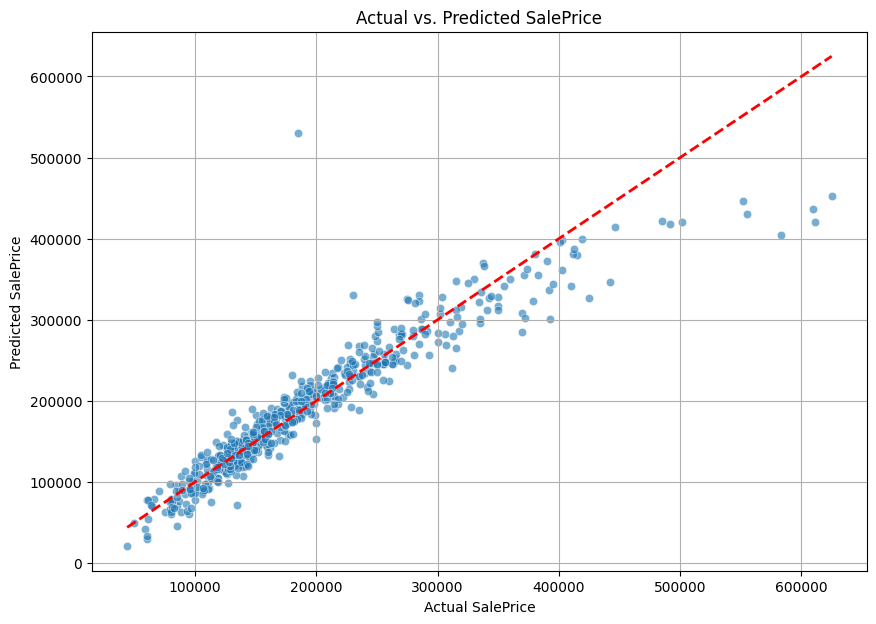

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs. Predicted SalePrice')
plt.grid(True)
plt.show()